# Impurity Metrics

## Prerequisites
Before proceeding with this chapter, students must have completed:

- Decision Tree basics
- Linear Regression [Performance metrics for regression]


## Learning Objectives
- Understand several impurity metrics used for the construction of decision trees.
- Compute gini, entropy, information gain and gain ratio.
- Discuss the issues with gini 


In the next chapter, we will discuss different algorithms used to create decision trees. But, before that, we need to discuss impurity metrics used by those algorithms. 

Decision Tree performs recursive partitioning of data to solve any problem. Partitions are made such that child nodes formed after partitioning are purer than the parent node (i.e. majority of the samples in the nodes belong to the same class). Depending upon the attribute chosen for splitting, the purity of child nodes vary. To quantify this purity(or impurity) of nodes in a decision tree and determine the best attribute to test, we use **impurity metrics**.

Some common impurity metrics are:

+ Gini
+ Entropy
+ Information Gain
+ Gain ratio
+ Mean Squared Error(MSE)


We discussed MSE in the reading material for linear regression. In this reading material, we will see how to compute impurity metrics other than MSE using the dataset shown below. Each row in this data represents a unique individual who is a customer of the bank(dummy bank): 

<div>
 
 <table>
 <caption>Dataset</caption>
 <tr>
 <th> Is Married</th>
 <th> Is house Owner</th>
 <th> Will repay loan</th>
 </tr>
 <tr>
 <td> false </td>
 <td> true </td>
 <td> yes </td>
 </tr>
 <tr>
 <td> true </td>
 <td> true </td>
 <td> yes </td>
 </tr>
 <tr>
 <td> true </td>
 <td> false </td>
 <td> no </td>
 </tr>
 <tr>
 <td> true </td>
 <td> false </td>
 <td> yes </td>
 </tr>
 </table>
</div>


The computation below only considers one feature, **Is house Owner**. However, computation for other features can be done similarly.


## Gini
Gini gives the probability of misclassifying a data point. It is a measure of impurity in the data. A higher gini value signifies higher impurity and vice-versa. Impurity, in general, depends upon the distribution of data. Uniformly distributed data have high impurity. Non-uniform data have lower impurity. For pure data, impurity is 0. 


<div align="center">
 <figure>
<p>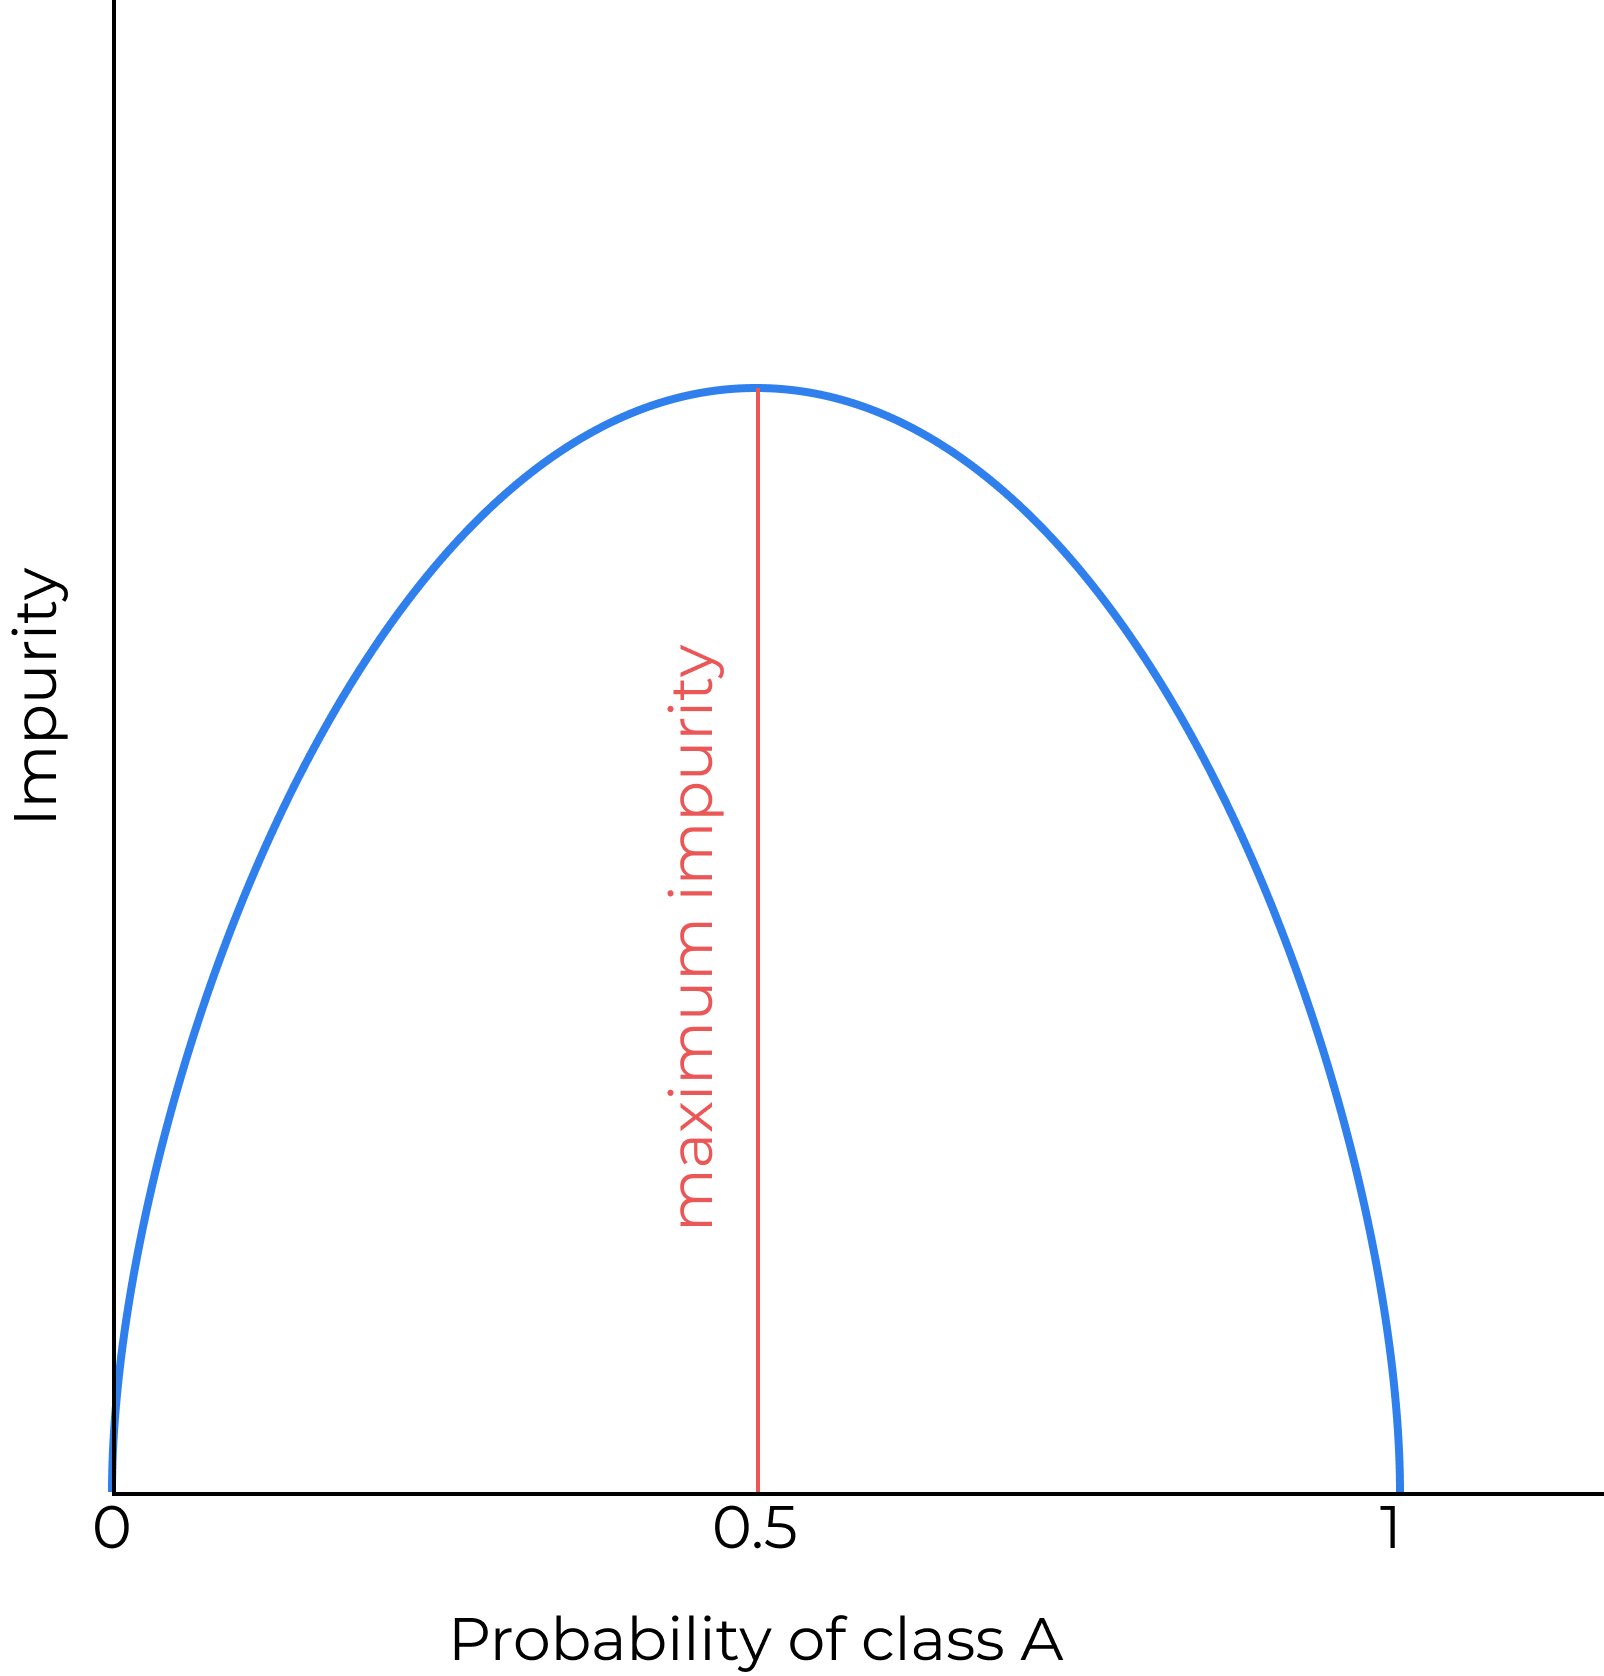</p>
 <figcaption>Figure 1: Impurity v/s probability of class A for a binary classification(class A and class B) problem.</figcaption>
 </figure>
</div>

From the graph above, we can see that, for the binary classification problem, if the ratio of number instances of each class is equal, i.e., the probability of getting any of the class is the same, the impurity is maximum. But if this ratio is not equal, impurity decreases and becomes 0 when all instances belong to a single class. 
<p>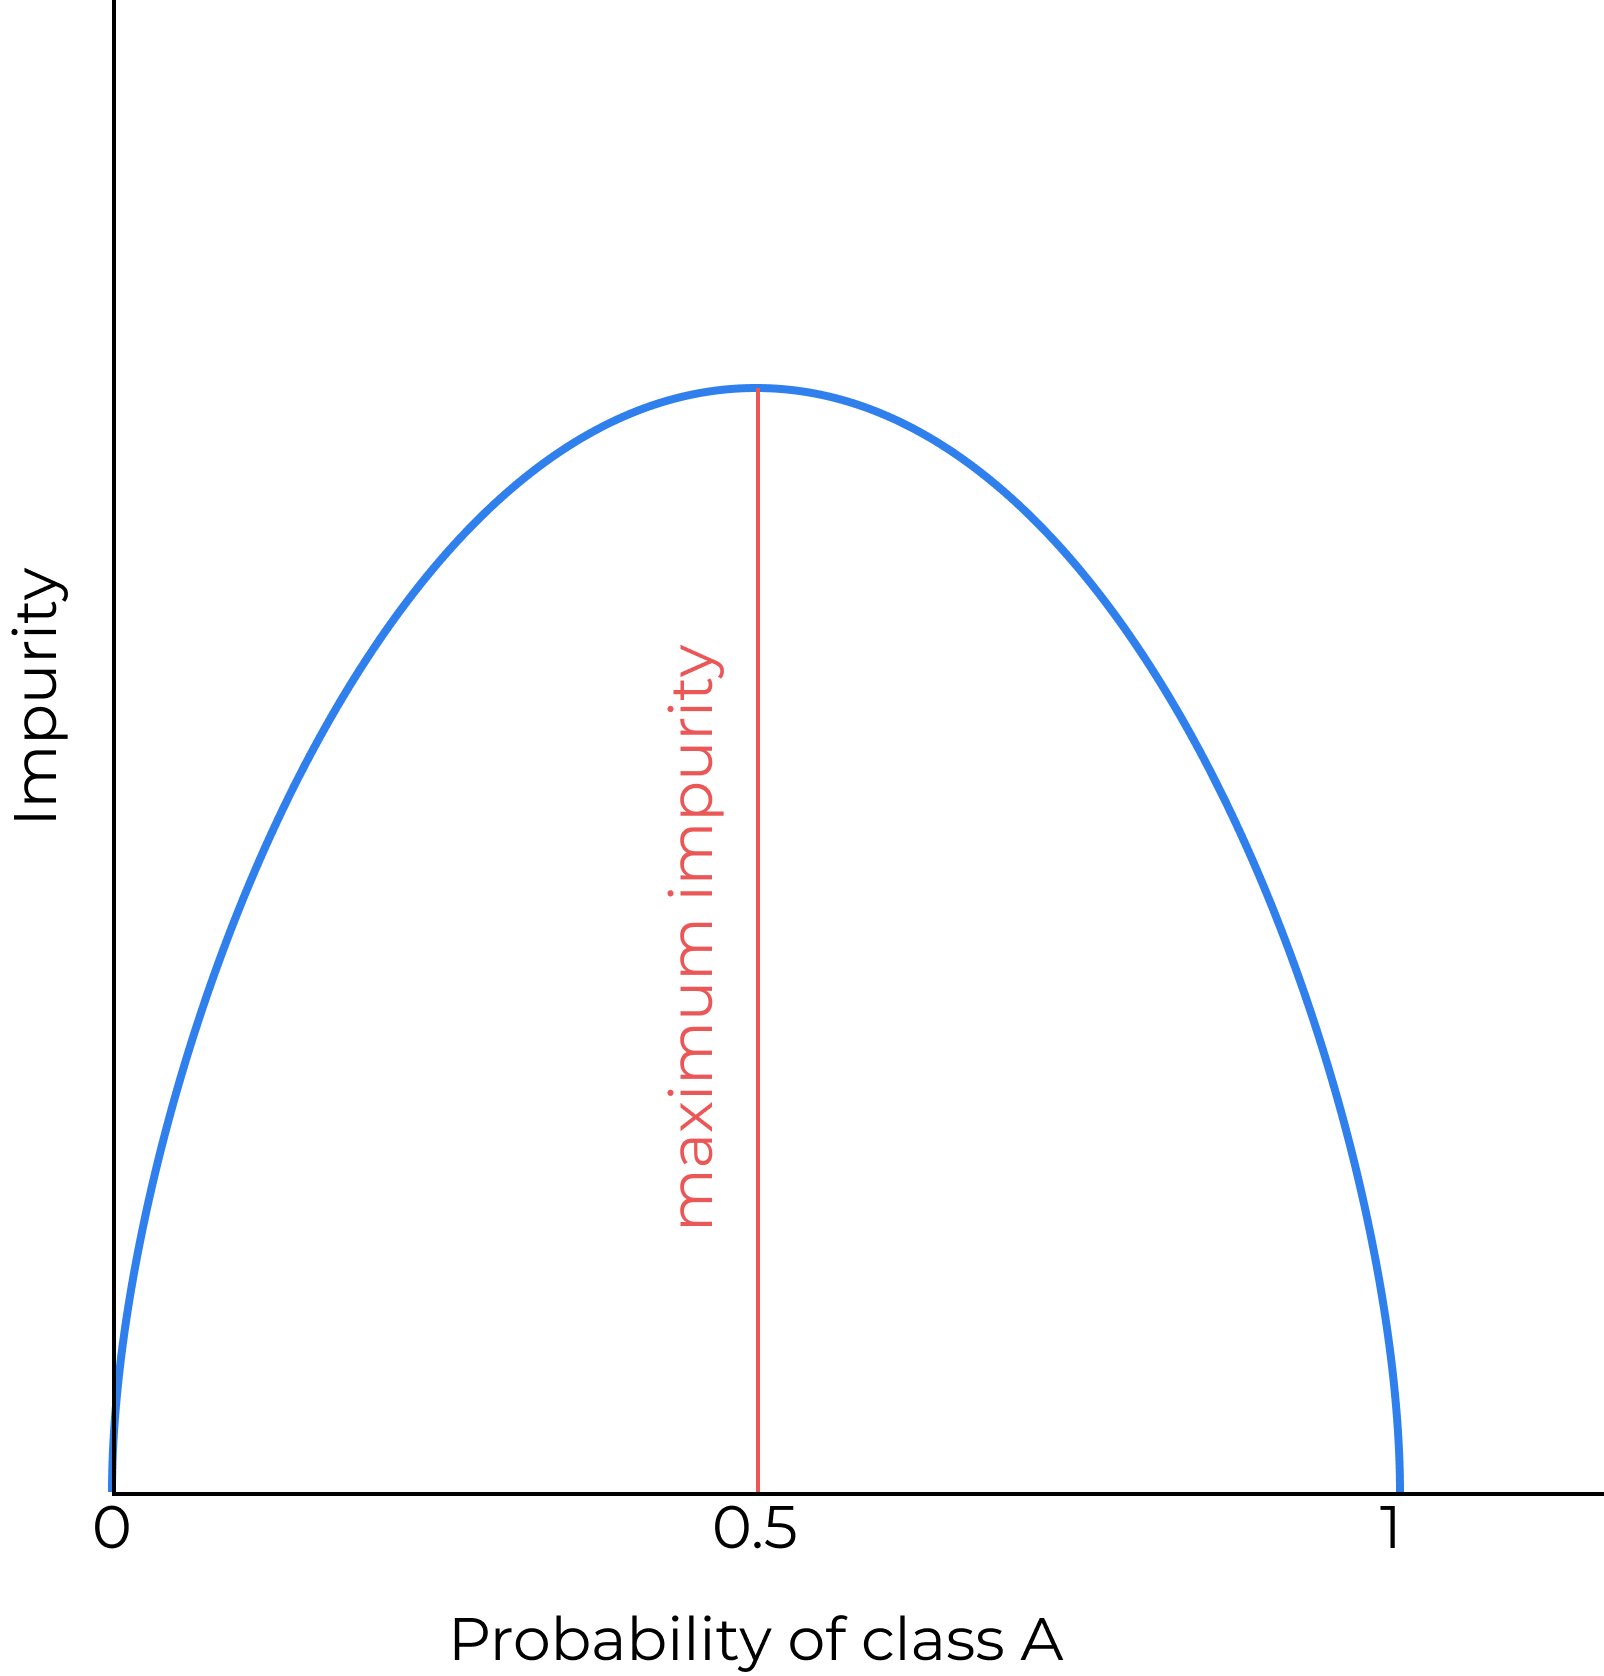</p>


Gini can be computed using the formula:   
$\text{Gini} = 1 - \sum_{i=1}^{c}{P_i^2}$   
Here,   
$c = $ Total number of labels/classes. 
$P_i = $ Probability of an item belonging to class $i$. 

There is a different way to compute gini for parent and child nodes. The example below illustrates the difference. 

For parent node,
We only consider the *label* or the *class*. In our case, **Will repay loan** is the final *label*. Three instances have label *yes* and one instance has the label *no*. So, 

\begin{eqnarray}
\text{Gini}_{parent} &=& 1 - [P_{\text{Will repay loan = yes}}^2+ P_{\text{Will repay loan = no}}^2] \\
 &=& 1 - [(\frac{3}{4})^2 + (\frac{1}{4})^2]\\
 &=& 0.375
\end{eqnarray}


For computing the gini impurity for child nodes, we split parent nodes using all attributes one at a time, find the gini impurity of each split, and then use weighted averaging to combine the gini impurity of all splits. The attribute that yields the lowest gini impurity in child nodes is chosen for testing. Let's see how it is done with the help of the example dataset. 

First, we will split the above dataset according to the value of attribute **Is house Owner**. The number of splits depends upon the number of values of an attribute $-$*n* valued attribute results in *n* splits. **Is house Owner** has two different values, *true* and *false*, resulting in 2 splits.

 <table>
 <caption>Split 1: Is house owner=true</caption>
 <tr>
 <th> Is Married</th>
 <th> Is house Owner</th>
 <th> Will repay loan</th>
 </tr>
 <tr>
 <td> false </td>
 <td> true </td>
 <td> yes </td>
 </tr>
 <tr>
 <td> true </td>
 <td> true </td>
 <td> yes </td>
 </tr>
 </table>
 <br>

 <table>
 <caption>Split 2: Is house owner=false</caption>
 <tr>
 <th> Is Married</th>
 <th> Is house Owner</th>
 <th> Will repay loan</th>
 </tr>
 <tr>
 <td> true </td>
 <td> false </td>
 <td> no </td>
 </tr>
 <tr>
 <td> true </td>
 <td> false </td>
 <td> yes </td>
 </tr>
 </table>



Gini for **Split 1**, **Is house owner** = *true*, can be computed as: 
\begin{eqnarray}
\text{Gini}_{split\ 1} &=& 1 - [P_{\text{Will repay loan = yes}}^2+ P_{\text{Will repay loan = no}}^2] \\
 &=& 1 - [(\frac{2}{2})^2 + 0]\\
 &=& 0
\end{eqnarray}

Similarly, Gini for **Split 2**, **Is house owner** = *false*, can be computed as: 
\begin{eqnarray}
\text{Gini}_{split\ 2} &=& 1 - [P_{\text{Will repay loan = yes}}^2+ P_{\text{Will repay loan = no}}^2] \\
 &=& 1 - [(\frac{1}{2})^2 + (\frac{1}{2})^2]\\
 &=& 0.5
\end{eqnarray}


Gini for the attribute **Is house owner** can be computed by taking a weighted average of $Gini_{split\ 1}$ and $Gini_{split\ 2}$. 

\begin{eqnarray}
\text{Gini}_\text{Is house owner} &=& \frac{2}{4} * \text{Gini}_{split\ 1} + \frac{2}{4} * \text{Gini}_{split\ 2}\\
 &=& \frac{2}{4} * 0 + \frac{2}{4} * 0.5\\
 &=& 0.25
\end{eqnarray}

Gini index for attribute **Is married** can be computed similarly, and it turns out to be $0.33$. An attribute that yields lower gini, in our case **Is house owner**, is preferred to make the split. 


## Entropy

Entropy is another metric to quantify impurity. It is a measure of disorder or randomness in data. It can be computed using the formula:  

$\text{Entropy} = - \sum_{i=1}^{c}P_i\log{P_i}$  
Here,  
$c = $ Total number of labels/classes.  
$p_i = $ Probability of an item belonging to class $i$. 

The process of computing entropy is very similar to that of computing gini. The only difference is the formula. Let us quickly compute entropy for parent and child nodes.  

For parent node,  
\begin{eqnarray}
\text{Entropy}_{parent} &=&-[P_{\text{Will repay loan = yes}} * \log_2({P_{\text{Will repay loan = yes}}})+ P_{\text{Will repay loan = no}} * \log_2({P_{\text{Will repay loan = no}}})] \\
 &=& -[\frac{3}{4} * \log_2{\frac{3}{4}} + \frac{1}{4} * \log_2{\frac{1}{4}} ]\\
 &=& 0.8112
\end{eqnarray}




For child nodes, 
First, like earlier, we will split the above dataset according to attribute **Is house Owner**. 


Entropy for **Split 1**(see table above), **Is house owner** = *true*, can be computed as: 
\begin{eqnarray}
\text{Entropy}_{split\ 1} &=&-[P_{\text{Will repay loan = yes}} * \log_2({P_{\text{Will repay loan = yes}}})+ P_{\text{Will repay loan = no}} * \log_2({P_{\text{Will repay loan = no}}})] \\
 &=& -[\frac{2}{2} * \log_2{\frac{2}{2}} + 0 ]\\
 &=& 0
\end{eqnarray}

Similarly, Entropy for **Split 2**, **Is house owner** = *false*, can be computed as: 
\begin{eqnarray}
\text{Entropy}_{split\ 2} &=&-[P_{\text{Will repay loan = yes}} * \log_2({P_{\text{Will repay loan = yes}}})+ P_{\text{Will repay loan = no}} * \log_2({P_{\text{Will repay loan = no}}})] \\
 &=& -[\frac{1}{2} * \log_2{\frac{1}{2}} + \frac{1}{2} * \log_2{\frac{1}{2}} ]\\
 &=& -[\frac{1}{2} * -1 + \frac{1}{2} * -1 ] \\
 &=& 1
\end{eqnarray}

Now, Entropy for the attribute **Is house owner** can be compute by taking a weighted average of $\text{Entropy}_{split\ 1} \text{and } \text{Entropy}_{split\ 2}$. 
\begin{eqnarray}
\text{Entropy}_\text{Is house owner} &=& \frac{2}{4} * \text{Entropy}_{split\ 1} + \frac{2}{4} * \text{Entropy}_{split\ 2}\\
 &=& \frac{2}{4} * 0 + \frac{2}{4} * 1\\
 &=& 0.5
\end{eqnarray}

Entropy for attribute **Is married** can be computed similarly, and it turns out to be $0.69$.


Both Gini and Entropy are used to compute impurity in data. But, computing gini is computationally more efficient than entropy as gini doesn't involve a logarithmic operation. 


## Information Gain

Information gain is the decrease in entropy after making a split. To compute information gain, we need: 
* Entropy before splitting the data, i.e., the entropy of the parent node
* Entropy after splitting the data, i.e., the entropy of child nodes
 





Now information gain can be computed using the formula: 
$\text{Information Gain}(G) = \text{Entropy}(L) - \text{Entropy}(L, A)$ 

where,   
$\text{Entropy}(L)=$ Entropy of parent node   
$ \text{Entropy}(L, A)=$ Entropy of child nodes after splitting parent node using attribute $A$   
$L$ = Label of the dataset 

For the above example, when split using attribute **Is house owner** information gain is: 
\begin{eqnarray}
G &=& \text{Entropy}_{Will\ repay\ loan} - \text{Entropy}_{Is\ house\ owner} \\
 &=& 0.8112 - 0.5\\
 &=& 0.3112
\end{eqnarray}

Similarly for the above example, when split using attribute **Is married** information gain is: 
\begin{eqnarray}
G &=& \text{Entropy}_{Will\ repay\ loan} - \text{Entropy}_{Is\ Married} \\
 &=& 0.8112 - 0.69\\
 &=& 0.1212
\end{eqnarray}

We can see splitting the attribute **Is house owner** yields higher information gain than splitting the attribute **Is Married**. The attribute that yields the highest information gain **Is house owner**, is preferred for testing.


## Gain Ratio

Both gini and entropy, hence information gain, prefer to split attributes having a higher number of unique values. For example, if we have an attribute, **ID**, with unique values for each data point in the training data, then gini and entropy will choose the **ID** attribute to make the split because it will generate pure instances.


<div align="center">
 <figure>
<p>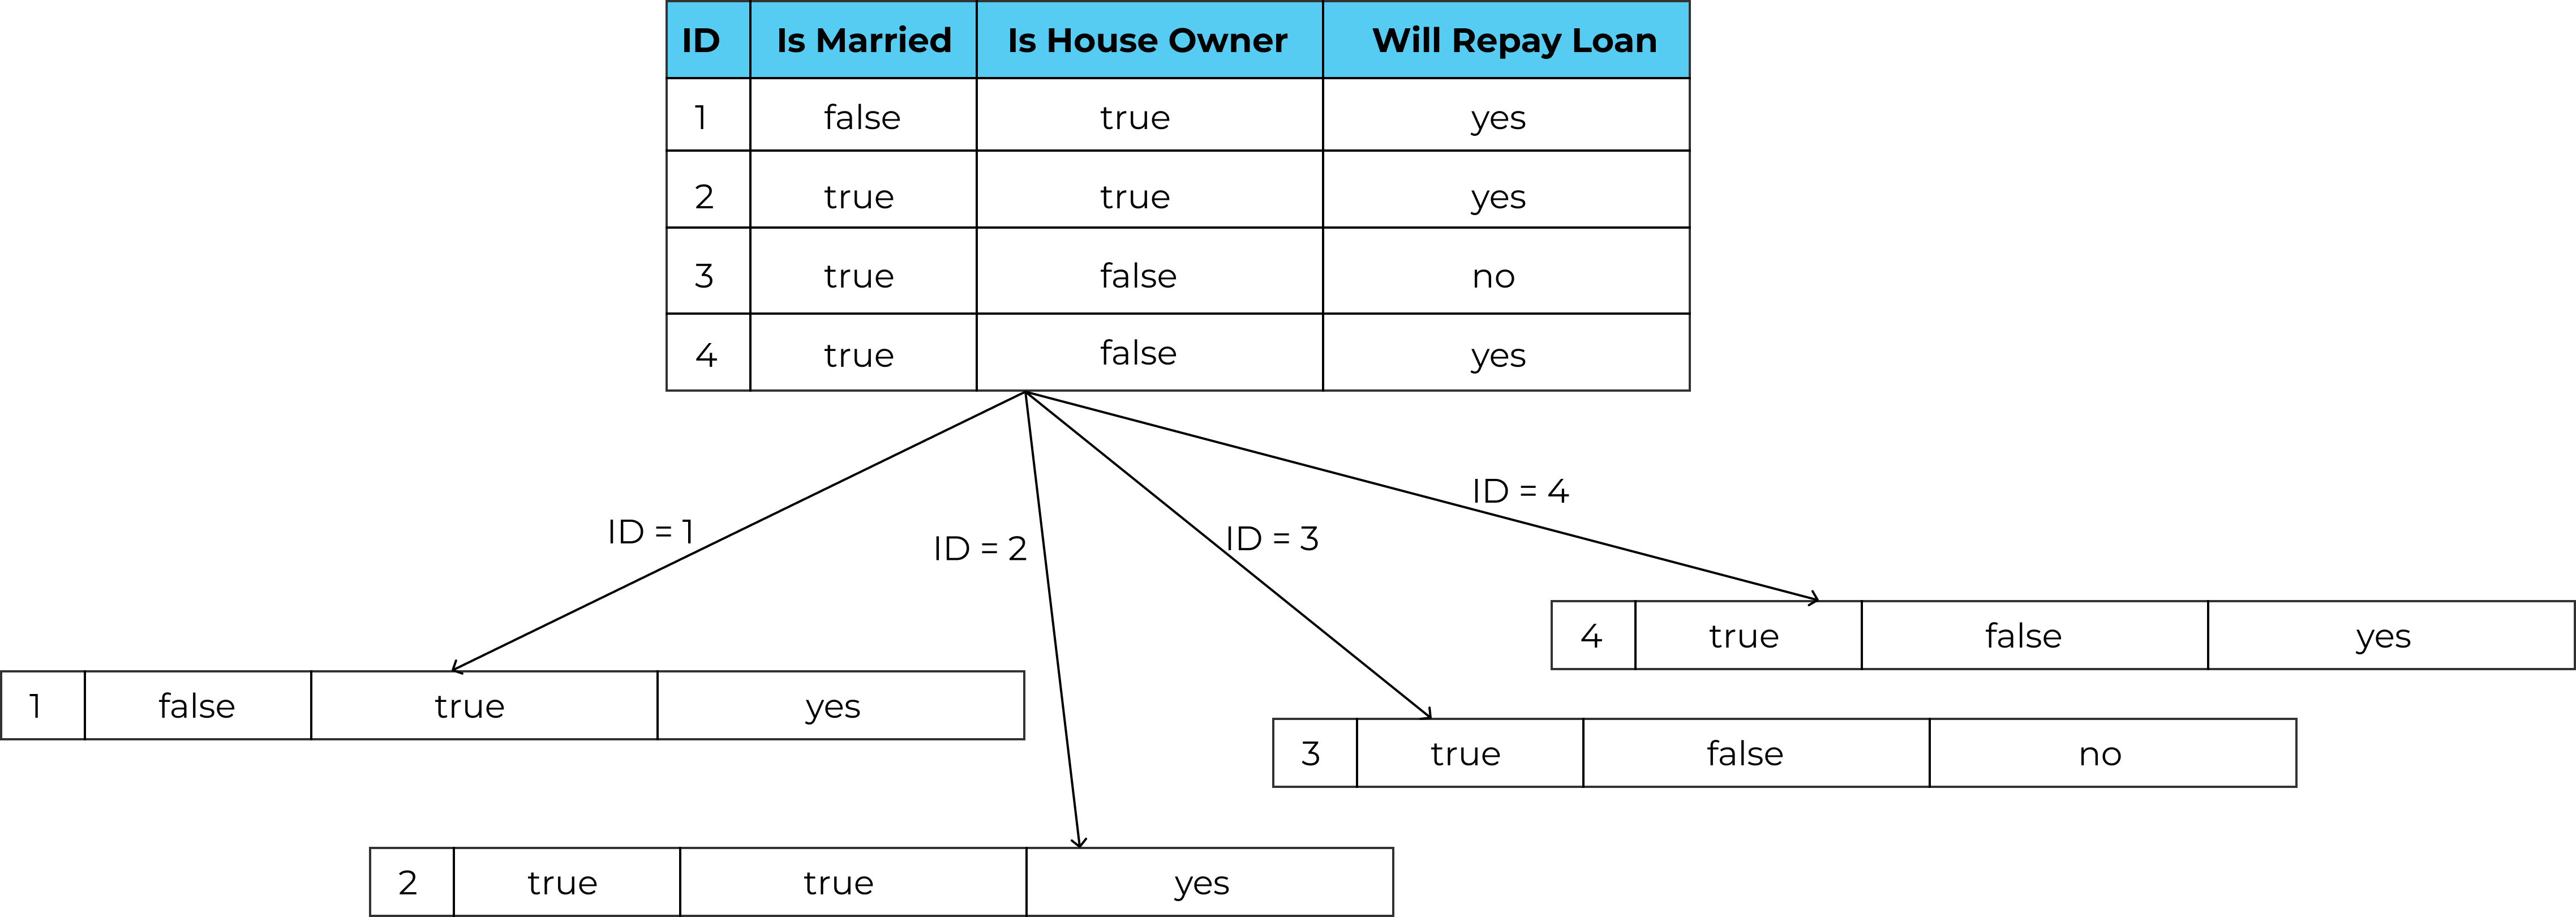</p>
 <figcaption>Figure 2: Splitting attribute ID results in pure instances</figcaption>
 </figure>
</div>

For parent node,  
\begin{eqnarray}
\text{Entropy}_{parent} &=&-[P_{\text{Will repay loan = yes}} * \log_2({P_{\text{Will repay loan = yes}}})+ P_{\text{Will repay loan = no}} * \log_2({P_{\text{Will repay loan = no}}})] \\
 &=& -[\frac{3}{4} * \log_2{\frac{3}{4}} + \frac{1}{4} * \log_2{\frac{1}{4}} ]\\
 &=& 0.8112
\end{eqnarray}

For child nodes, 
First, like earlier, we will split the above dataset according to attribute **ID**. 


Entropy for **Split 1**(see table above), **ID** = *1*, can be computed as: 
\begin{eqnarray}
\text{Entropy}_{split\ 1} &=&-[P_{\text{Will repay loan = yes}} * \log_2({P_{\text{Will repay loan = yes}}})+ P_{\text{Will repay loan = no}} * \log_2({P_{\text{Will repay loan = no}}})] \\
 &=& -[\frac{1}{1} * \log_2{\frac{1}{1}} + 0 ]\\
 &=& 0
\end{eqnarray}

Similarly, Entropy for  all remaining split will be 0. 

Now, Entropy for the attribute **ID** can be compute by taking a weighted average as:  
\begin{eqnarray}
\text{Entropy}_\text{ID} &=& \frac{1}{4} * \text{Entropy}_{split\ 1} + \frac{1}{4} * \text{Entropy}_{split\ 2}+\frac{1}{4} * \text{Entropy}_{split\ 3} + \frac{1}{4} * \text{Entropy}_{split\ 4}\\
 &=& \frac{1}{4} * 0 + \frac{1}{4} * 0 + \frac{1}{4} * 0 +\frac{1}{4} * 0\\
 &=& 0
\end{eqnarray}

Thus, the **Information Gain** using **ID** attribute can be calculated as:
\begin{eqnarray}
G &=& \text{Entropy}_{Will\ repay\ loan} - \text{Entropy}_{ID} \\
 &=& 0.8112 - 0\\
 &=& 0.8112
\end{eqnarray}

This may result in a poor decision tree classifier. In the worst case, like ours, the decision tree fails to classify unseen instances. In the test data, we may have an instance with id $5$, and the classifier will fail to classify this instance as it doesn't belong to any of the child nodes in the figure above. 

**Gain ratio** solves this issue, preference for attribute with higher number of distinct values, by using **split entropy**. Gain ratio can be computed using the formula: 
 

$\text{Gain Ratio(L, A)} = \frac{Information\ Gain(G)}{Split\ Entropy(L,\ A)}$

where,   
$L = $ label of dataset   
$A = $ an attribute of dataset   

$Split\ Entropy(L, A)$ is computed as:  
$- \sum_{v}p_v\log{p_v}$   

where,   
$p_v =$ probability of an attribute taking value $v$.  

If an attribute has many distinct values, split entropy becomes higher, which causes the gain ratio to decrease. In this way, attributes with a higher number of unique values get penalized. 
 
We can compute $Split\ Entropy(L, A)$ for **Is house owner** as follows: 

\begin{eqnarray}
Split\ Entropy(L, A) &=& -\sum_v p_v \log p_v \\
 &=& -[p_{HO = true} * log_2 \ p_{HO = true} + p_{HO = false} * log_2 \ p_{HO = false}]\\
 &=& -[\frac{2}{4}* \log_2\frac{2}{4} + \frac{2}{4}* \log_2\frac{2}{4}] \\
 &=& 1 
\end{eqnarray}


Hence, we can now compute gain ratio as: 
\begin{eqnarray}
Gain\ Ratio(L, A) &=& \frac{Information\ Gain(G)}{Split\ Entropy(L,\ A)} \\
&=& \frac{0.3112}{1} \\
&=& 0.3112
\end{eqnarray}

Similarly, for **ID**, 
\begin{eqnarray}
Split\ Entropy(L, A) &=& -\sum_v p_v \log p_v \\
 &=& -[p_{ID = 1} * log_2 \ p_{ID = 1} + p_{ID = 2} * log_2 \ p_{ID = 2}+ p_{ID = 3} * log_2 \ p_{ID = 3} + p_{ID = 4} * log_2 \ p_{ID = 4}]\\
 &=& -[\frac{1}{4}* \log_2\frac{1}{4} + \frac{1}{4}* \log_2\frac{1}{4}+\frac{1}{4}* \log_2\frac{1}{4} + \frac{1}{4}* \log_2\frac{1}{4}] \\
 &=& 2 
\end{eqnarray}
Hence, we can now compute gain ratio as:
\begin{eqnarray}
Gain\ Ratio(L, A) &=& \frac{0.8112}{2} \\
&=& 0.4056
\end{eqnarray}



Similarly, for **Is Married**, 
\begin{eqnarray}
Split\ Entropy(L, A) &=& -\sum_v p_v \log p_v \\
 &=& -[p_{M = true} * log_2 \ p_{M = true} + p_{M = false} * log_2 \ p_{M = false}]\\
 &=& -[\frac{3}{4}* \log_2\frac{3}{4} + \frac{1}{4}* \log_2\frac{1}{4}] \\
 &=& 0.8112
\end{eqnarray}

Hence, we can now compute gain ratio as:
\begin{eqnarray}
Gain\ Ratio(L, A) &=& \frac{0.1212}{0.8112} \\
&=& 0.1494
\end{eqnarray}

The attribute **ID** has been penalized by gain ratio for having a higher number of unique values. But, the gain ratio for **ID** is still higher than other attributes. This is because of the small dataset we have. In a larger dataset, the advantages of the gain ratio over gini and entropy are more apparent. 

In this notebook, we discussed how we could compute impurity metrics for discrete attributes. In the next notebook, we will demonstrate how we can handle continuous attributes. 




## Key Takeaways

* Impurity metrics give a measure of impurity in the data.
* Impurity is highest when all classes have an equal number of instances, impurity decreases as the distribution of classes becomes non-uniform and is 0 when the data is pure. 
* Split that yields lower gini or entropy is better than split that yields higher gini or entropy. 
* Split that yields higher information gain or gain ratio is better than split that yields lower information gain and gain ratio. 
* Gain ratio penalizes attributes that have a higher number of unique values. 




## Additional Resources

### Impurity Metrics

* [Classification: Basic Concepts, Basic Concepts, Decision Trees, and Model Evaluation](https://www-users.cs.umn.edu/~kumar001/dmbook/ch4.pdf) 
 Refer to section 4.3.4 to read about impurity metrics.


